In [1]:
from pathlib import Path
import importlib.util
import random

required_modules = [
    "torch",
    "cv2",
    "numpy",
    "pandas",
    "matplotlib",
    "tqdm",
]

missing_modules = [name for name in required_modules if importlib.util.find_spec(name) is None]

if missing_modules:
    raise ModuleNotFoundError(
        "Missing required package(s): "
        + ", ".join(missing_modules)
        + "\nInstall them in the active notebook kernel before continuing."
    )

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from IPython.display import display

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["image.cmap"] = "gray"

SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print("All required packages are available.")


All required packages are available.


In [2]:
NOTEBOOK_DIR = Path.cwd().resolve()
SEGMENTATION_ROOT = NOTEBOOK_DIR.parent
DATA_ROOT = SEGMENTATION_ROOT / "data"
RESULTS_ROOT = SEGMENTATION_ROOT / "results"

FIGURES_DIR = RESULTS_ROOT / "figures"
METRICS_DIR = RESULTS_ROOT / "metrics"
MODELS_DIR = RESULTS_ROOT / "models"

dataset_root = DATA_ROOT / "EchoNet-Dynamic"
filelist_path = dataset_root / "FileList.csv"
tracings_path = dataset_root / "VolumeTracings.csv"
videos_dir = dataset_root / "Videos"

checkpoint_path = MODELS_DIR / "unet_baseline_112_rgb_kaggle_best.pt"
training_history_path = METRICS_DIR / "unet_baseline_112_rgb_kaggle_history.csv"
frame_level_path = METRICS_DIR / "frame_level_df_with_metadata.csv"

EVAL_RUN_NAME = "unet_baseline_112_rgb_kaggle_eval"

sample_metrics_path = METRICS_DIR / f"{EVAL_RUN_NAME}_sample_metrics.csv"
split_summary_path = METRICS_DIR / f"{EVAL_RUN_NAME}_split_summary.csv"
phase_summary_path = METRICS_DIR / f"{EVAL_RUN_NAME}_phase_summary.csv"
overview_figure_path = FIGURES_DIR / f"{EVAL_RUN_NAME}_overview.png"
qualitative_figure_path = FIGURES_DIR / f"{EVAL_RUN_NAME}_qualitative_examples.png"

FRAME_HEIGHT = 112
FRAME_WIDTH = 112
IMAGE_SHAPE = (FRAME_HEIGHT, FRAME_WIDTH)
THRESHOLD = 0.5
BATCH_SIZE = 32
NUM_WORKERS = 0

def resolve_device():
    if torch.cuda.is_available():
        try:
            device = torch.device("cuda")
            probe = torch.zeros(1, device=device)
            _ = probe + 1
            torch.cuda.synchronize()
            return device, f"Using CUDA on {torch.cuda.get_device_name(0)}"
        except Exception as exc:
            return torch.device("cpu"), f"CUDA detected but unusable. Falling back to CPU. Reason: {type(exc).__name__}: {exc}"

    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps"), "Using Apple MPS"

    return torch.device("cpu"), "Using CPU"

device, device_message = resolve_device()
pin_memory = device.type == "cuda"

print("dataset_root:", dataset_root)
print("checkpoint_path exists:", checkpoint_path.exists())
print("training_history_path exists:", training_history_path.exists())
print("frame_level_path exists:", frame_level_path.exists())
print("device:", device)
print("device_message:", device_message)


dataset_root: /Users/emirarslan/Downloads/lab task/echo-project/segmentation/data/EchoNet-Dynamic
checkpoint_path exists: True
training_history_path exists: True
frame_level_path exists: True
device: mps
device_message: Using Apple MPS


In [3]:
assert filelist_path.exists(), f"Missing file: {filelist_path}"
assert tracings_path.exists(), f"Missing file: {tracings_path}"
assert videos_dir.exists(), f"Missing directory: {videos_dir}"
assert checkpoint_path.exists(), f"Missing checkpoint: {checkpoint_path}"
assert training_history_path.exists(), f"Missing history file: {training_history_path}"

file_df = pd.read_csv(filelist_path)
trace_df = pd.read_csv(tracings_path)
trace_df["FileStem"] = trace_df["FileName"].str.replace(".avi", "", regex=False)

training_history_df = pd.read_csv(training_history_path)

file_names = set(file_df["FileName"].astype(str))
trace_names = set(trace_df["FileStem"].astype(str))

traceable_video_names = sorted(file_names & trace_names)
missing_trace_video_names = sorted(file_names - trace_names)
extra_trace_video_names = sorted(trace_names - file_names)

assert len(traceable_video_names) == 10024
assert len(missing_trace_video_names) == 6
assert len(extra_trace_video_names) == 1

print("file_df shape:", file_df.shape)
print("trace_df shape:", trace_df.shape)
print("training_history_df shape:", training_history_df.shape)
print("traceable videos:", len(traceable_video_names))

best_training_row = training_history_df.loc[training_history_df["val_dice"].idxmax()]
print("Best training epoch:")
display(best_training_row.to_frame(name="value"))


file_df shape: (10030, 9)
trace_df shape: (425010, 7)
training_history_df shape: (20, 12)
traceable videos: 10024
Best training epoch:


,value
epoch,17.000000
lr,0.000500
train_loss,0.064208
train_bce,0.041219
train_dice_loss,0.087196
train_dice,0.922509
train_iou,0.859448
val_loss,0.063503
val_bce,0.040887
val_dice_loss,0.086120


In [4]:
def resolve_video_path(file_name: str, videos_dir: Path) -> Path:
    candidate_1 = videos_dir / file_name
    candidate_2 = videos_dir / f"{file_name}.avi"

    if candidate_1.exists():
        return candidate_1
    if candidate_2.exists():
        return candidate_2

    raise FileNotFoundError(f"Could not resolve video path for: {file_name}")


def load_frame(video_path: Path, frame_index: int) -> np.ndarray:
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
    ok, frame = cap.read()
    cap.release()

    if not ok:
        raise ValueError(f"Could not read frame {frame_index} from {video_path}")

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return frame


def get_video_trace_rows(file_stem: str, trace_df: pd.DataFrame) -> pd.DataFrame:
    rows = trace_df[trace_df["FileStem"] == file_stem].copy()
    if rows.empty:
        raise ValueError(f"No tracing rows found for {file_stem}")
    return rows


def get_traced_frames_for_video(file_stem: str, trace_df: pd.DataFrame):
    rows = get_video_trace_rows(file_stem, trace_df)
    frames = sorted(rows["Frame"].unique().tolist())
    return frames


def get_frame_trace_points(file_stem: str, frame_index: int, trace_df: pd.DataFrame) -> np.ndarray:
    rows = trace_df[
        (trace_df["FileStem"] == file_stem) &
        (trace_df["Frame"] == frame_index)
    ].copy()

    if rows.empty:
        raise ValueError(f"No trace rows found for {file_stem} frame {frame_index}")

    points = rows[["X1", "Y1", "X2", "Y2"]].to_numpy(dtype=np.float32)
    return points


def tracing_points_to_polygon_vertices(points: np.ndarray) -> np.ndarray:
    x1 = points[:, 0]
    y1 = points[:, 1]
    x2 = points[:, 2]
    y2 = points[:, 3]

    x = np.concatenate((x1[1:], np.flip(x2[1:])))
    y = np.concatenate((y1[1:], np.flip(y2[1:])))

    vertices = np.stack([x, y], axis=1)
    return vertices


def polygon_vertices_to_mask(vertices: np.ndarray, image_shape: tuple[int, int]) -> np.ndarray:
    height, width = image_shape

    polygon_points = np.rint(vertices).astype(np.int32).reshape(-1, 1, 2)
    polygon_points[:, 0, 0] = np.clip(polygon_points[:, 0, 0], 0, width - 1)
    polygon_points[:, 0, 1] = np.clip(polygon_points[:, 0, 1], 0, height - 1)

    mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(mask, [polygon_points], 1)
    return mask


def build_mask_from_points(points: np.ndarray, image_shape: tuple[int, int]) -> np.ndarray:
    vertices = tracing_points_to_polygon_vertices(points)
    mask = polygon_vertices_to_mask(vertices, image_shape=image_shape)
    return mask


In [5]:
trace_lookup = {
    (str(file_stem), int(frame_idx)): rows[["X1", "Y1", "X2", "Y2"]].to_numpy(dtype=np.float32)
    for (file_stem, frame_idx), rows in trace_df.groupby(["FileStem", "Frame"], sort=False)
}

video_path_map = {
    file_stem: resolve_video_path(file_stem, videos_dir)
    for file_stem in traceable_video_names
}

if frame_level_path.exists():
    frame_level_df = pd.read_csv(frame_level_path)
    print("Loaded cached frame_level_df from:", frame_level_path)
else:
    frame_level_rows = []

    for file_stem in tqdm(traceable_video_names, desc="Building frame_level_df"):
        frames = get_traced_frames_for_video(file_stem, trace_df)
        frame_area_pairs = []

        for frame_idx in frames:
            points = trace_lookup[(file_stem, int(frame_idx))]
            mask = build_mask_from_points(points, IMAGE_SHAPE)
            frame_area_pairs.append((int(frame_idx), int(mask.sum())))

        frame_area_pairs = sorted(frame_area_pairs, key=lambda x: x[1])

        if len(frame_area_pairs) != 2:
            raise ValueError(f"Expected exactly 2 traced frames for {file_stem}, got {len(frame_area_pairs)}")

        es_frame, es_area = frame_area_pairs[0]
        ed_frame, ed_area = frame_area_pairs[1]

        frame_level_rows.append({
            "FileName": file_stem,
            "Frame": es_frame,
            "Phase": "ES",
            "MaskArea": es_area,
        })
        frame_level_rows.append({
            "FileName": file_stem,
            "Frame": ed_frame,
            "Phase": "ED",
            "MaskArea": ed_area,
        })

    frame_level_df = pd.DataFrame(frame_level_rows)
    frame_level_df = frame_level_df.merge(
        file_df[["FileName", "EF", "ESV", "EDV", "FrameHeight", "FrameWidth", "FPS", "NumberOfFrames", "Split"]],
        on="FileName",
        how="left",
        validate="many_to_one",
    )

frame_level_df["Frame"] = frame_level_df["Frame"].astype(int)
frame_level_df["MaskArea"] = frame_level_df["MaskArea"].astype(int)
frame_level_df = frame_level_df.sort_values(["Split", "FileName", "Frame"]).reset_index(drop=True)

expected_split_counts = {"TRAIN": 14920, "VAL": 2576, "TEST": 2552}
observed_split_counts = frame_level_df["Split"].value_counts().to_dict()

assert len(frame_level_df) == 20048
assert observed_split_counts == expected_split_counts, observed_split_counts

val_df = frame_level_df[frame_level_df["Split"] == "VAL"].copy().reset_index(drop=True)
test_df = frame_level_df[frame_level_df["Split"] == "TEST"].copy().reset_index(drop=True)

print("trace_lookup size:", len(trace_lookup))
print("video_path_map size:", len(video_path_map))
print("frame_level_df shape:", frame_level_df.shape)
print("val_df shape:", val_df.shape)
print("test_df shape:", test_df.shape)

display(frame_level_df.head())
display(pd.crosstab(frame_level_df["Split"], frame_level_df["Phase"]))


Loaded cached frame_level_df from: /Users/emirarslan/Downloads/lab task/echo-project/segmentation/results/metrics/frame_level_df_with_metadata.csv
trace_lookup size: 20050
video_path_map size: 10024
frame_level_df shape: (20048, 12)
val_df shape: (2576, 12)
test_df shape: (2552, 12)


,FileName,Frame,Phase,MaskArea,EF,ESV,EDV,FrameHeight,FrameWidth,FPS,NumberOfFrames,Split
0,0X100CF05D141FF143,132,ED,1339,55.951790,47.453831,107.731578,112,112,50,248,TEST
1,0X100CF05D141FF143,148,ES,801,55.951790,47.453831,107.731578,112,112,50,248,TEST
2,0X1012703CDC1436FE,154,ED,2298,41.014425,71.379125,121.011152,112,112,50,201,TEST
3,0X1012703CDC1436FE,172,ES,1674,41.014425,71.379125,121.011152,112,112,50,201,TEST
4,0X102CFB07F752AAE6,163,ED,1508,50.794718,33.947173,68.990913,112,112,54,217,TEST


Phase,ED,ES
Split,,
TEST,1276,1276
TRAIN,7460,7460
VAL,1288,1288


In [6]:
class EchoNetFrameSegmentationDataset(Dataset):
    def __init__(
        self,
        frame_df: pd.DataFrame,
        video_path_map: dict,
        trace_lookup: dict,
        image_shape: tuple[int, int] = (112, 112),
    ):
        self.frame_df = frame_df.reset_index(drop=True).copy()
        self.video_path_map = video_path_map
        self.trace_lookup = trace_lookup
        self.image_shape = image_shape

    def __len__(self):
        return len(self.frame_df)

    def __getitem__(self, idx: int):
        row = self.frame_df.iloc[idx]

        file_stem = row["FileName"]
        frame_idx = int(row["Frame"])

        frame = load_frame(self.video_path_map[file_stem], frame_idx).astype(np.float32) / 255.0
        if frame.shape[:2] != self.image_shape:
            raise ValueError(f"Unexpected frame shape for {file_stem}: {frame.shape[:2]}")

        points = self.trace_lookup[(file_stem, frame_idx)]
        mask = build_mask_from_points(points, image_shape=self.image_shape).astype(np.float32)

        image_tensor = torch.from_numpy(np.transpose(frame, (2, 0, 1))).float()
        mask_tensor = torch.from_numpy(mask[None, ...]).float()

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "file_name": file_stem,
            "frame": frame_idx,
            "phase": row["Phase"],
            "split": row["Split"],
        }


class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, skip_channels: int, out_channels: int):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels: int = 3, out_channels: int = 1, base_channels: int = 32):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, base_channels)
        self.enc2 = DownBlock(base_channels, base_channels * 2)
        self.enc3 = DownBlock(base_channels * 2, base_channels * 4)
        self.enc4 = DownBlock(base_channels * 4, base_channels * 8)
        self.bottleneck = DownBlock(base_channels * 8, base_channels * 16)

        self.dec4 = UpBlock(base_channels * 16, base_channels * 8, base_channels * 8)
        self.dec3 = UpBlock(base_channels * 8, base_channels * 4, base_channels * 4)
        self.dec2 = UpBlock(base_channels * 4, base_channels * 2, base_channels * 2)
        self.dec1 = UpBlock(base_channels * 2, base_channels, base_channels)

        self.out_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(x1)
        x3 = self.enc3(x2)
        x4 = self.enc4(x3)
        x5 = self.bottleneck(x4)

        x = self.dec4(x5, x4)
        x = self.dec3(x, x3)
        x = self.dec2(x, x2)
        x = self.dec1(x, x1)

        return self.out_conv(x)


In [7]:
checkpoint = torch.load(checkpoint_path, map_location=device)

model = UNet(in_channels=3, out_channels=1, base_channels=32).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

val_dataset = EchoNetFrameSegmentationDataset(
    frame_df=val_df,
    video_path_map=video_path_map,
    trace_lookup=trace_lookup,
    image_shape=IMAGE_SHAPE,
)

test_dataset = EchoNetFrameSegmentationDataset(
    frame_df=test_df,
    video_path_map=video_path_map,
    trace_lookup=trace_lookup,
    image_shape=IMAGE_SHAPE,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

print("Checkpoint keys:", checkpoint.keys())
print("Checkpoint epoch:", checkpoint.get("epoch"))
print("Checkpoint best_val_dice:", checkpoint.get("best_val_dice"))
print("len(val_dataset):", len(val_dataset))
print("len(test_dataset):", len(test_dataset))
print("len(val_loader):", len(val_loader))
print("len(test_loader):", len(test_loader))


Checkpoint keys: dict_keys(['epoch', 'best_val_dice', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'run_config', 'history'])
Checkpoint epoch: 17
Checkpoint best_val_dice: 0.9231945868604672
len(val_dataset): 2576
len(test_dataset): 2552
len(val_loader): 81
len(test_loader): 80


In [8]:
def compute_binary_metrics(pred_mask: np.ndarray, true_mask: np.ndarray, eps: float = 1e-6):
    pred_mask = pred_mask.astype(bool)
    true_mask = true_mask.astype(bool)

    intersection = np.logical_and(pred_mask, true_mask).sum()
    union = np.logical_or(pred_mask, true_mask).sum()
    pred_area = pred_mask.sum()
    true_area = true_mask.sum()

    dice = (2.0 * intersection + eps) / (pred_area + true_area + eps)
    iou = (intersection + eps) / (union + eps)
    precision = (intersection + eps) / (pred_area + eps)
    recall = (intersection + eps) / (true_area + eps)

    return {
        "Dice": float(dice),
        "IoU": float(iou),
        "Precision": float(precision),
        "Recall": float(recall),
        "PredArea": int(pred_area),
        "TrueArea": int(true_area),
        "AreaError": int(pred_area - true_area),
    }


@torch.no_grad()
def evaluate_loader(model, loader, device, threshold: float = 0.5):
    rows = []

    for batch in tqdm(loader, desc="Evaluating", leave=False):
        images = batch["image"].to(device, non_blocking=(device.type == "cuda"))
        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy()[:, 0]
        true_masks = batch["mask"].cpu().numpy()[:, 0]

        file_names = list(batch["file_name"])
        frames = batch["frame"].tolist()
        phases = list(batch["phase"])
        splits = list(batch["split"])

        for i in range(len(file_names)):
            pred_mask = (probs[i] >= threshold).astype(np.uint8)
            true_mask = (true_masks[i] >= 0.5).astype(np.uint8)

            metric_row = compute_binary_metrics(pred_mask, true_mask)
            metric_row.update({
                "FileName": file_names[i],
                "Frame": int(frames[i]),
                "Phase": phases[i],
                "Split": splits[i],
                "Threshold": float(threshold),
            })
            rows.append(metric_row)

    return pd.DataFrame(rows)


def flatten_agg_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [
        "_".join([str(part) for part in col if str(part) != ""])
        for col in df.columns.to_flat_index()
    ]
    return df.reset_index()


In [9]:
val_eval_df = evaluate_loader(
    model=model,
    loader=val_loader,
    device=device,
    threshold=THRESHOLD,
)

test_eval_df = evaluate_loader(
    model=model,
    loader=test_loader,
    device=device,
    threshold=THRESHOLD,
)

sample_metrics_df = pd.concat([val_eval_df, test_eval_df], ignore_index=True)

sample_metrics_df = sample_metrics_df.merge(
    frame_level_df[["FileName", "Frame", "Phase", "Split", "EF", "ESV", "EDV", "MaskArea"]],
    on=["FileName", "Frame", "Phase", "Split"],
    how="left",
    validate="one_to_one",
)

metric_cols = ["Dice", "IoU", "Precision", "Recall"]

split_summary_df = flatten_agg_columns(
    sample_metrics_df.groupby("Split")[metric_cols].agg(["mean", "std", "median"])
)

phase_summary_df = flatten_agg_columns(
    sample_metrics_df.groupby(["Split", "Phase"])[metric_cols].agg(["mean", "std", "median"])
)

sample_metrics_df.to_csv(sample_metrics_path, index=False)
split_summary_df.to_csv(split_summary_path, index=False)
phase_summary_df.to_csv(phase_summary_path, index=False)

print("Saved sample metrics to:", sample_metrics_path)
print("Saved split summary to:", split_summary_path)
print("Saved phase summary to:", phase_summary_path)

print("\nSplit summary:")
display(split_summary_df)

print("\nPhase summary:")
display(phase_summary_df)

print("\nBest TEST examples by Dice:")
display(
    sample_metrics_df[sample_metrics_df["Split"] == "TEST"]
    .nlargest(5, "Dice")[["FileName", "Frame", "Phase", "Dice", "IoU", "PredArea", "TrueArea"]]
)

print("\nWorst TEST examples by Dice:")
display(
    sample_metrics_df[sample_metrics_df["Split"] == "TEST"]
    .nsmallest(5, "Dice")[["FileName", "Frame", "Phase", "Dice", "IoU", "PredArea", "TrueArea"]]
)


Evaluating:   0%|          | 0/81 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

Saved sample metrics to: /Users/emirarslan/Downloads/lab task/echo-project/segmentation/results/metrics/unet_baseline_112_rgb_kaggle_eval_sample_metrics.csv
Saved split summary to: /Users/emirarslan/Downloads/lab task/echo-project/segmentation/results/metrics/unet_baseline_112_rgb_kaggle_eval_split_summary.csv
Saved phase summary to: /Users/emirarslan/Downloads/lab task/echo-project/segmentation/results/metrics/unet_baseline_112_rgb_kaggle_eval_phase_summary.csv

Split summary:


,Split,Dice_mean,Dice_std,Dice_median,IoU_mean,IoU_std,IoU_median,Precision_mean,Precision_std,Precision_median,Recall_mean,Recall_std,Recall_median
0,TEST,0.923153,0.041681,0.932944,0.859828,0.066276,0.874316,0.916666,0.072387,0.934194,0.936546,0.057526,0.951919
1,VAL,0.923193,0.040123,0.932487,0.859742,0.064595,0.873513,0.916487,0.069303,0.933139,0.936409,0.057043,0.950866



Phase summary:


,Split,Phase,Dice_mean,Dice_std,Dice_median,IoU_mean,IoU_std,IoU_median,Precision_mean,Precision_std,Precision_median,Recall_mean,Recall_std,Recall_median
0,TEST,ED,0.934411,0.031902,0.941716,0.878463,0.052577,0.889852,0.932608,0.056240,0.946437,0.941251,0.054054,0.956021
1,TEST,ES,0.911895,0.046954,0.923022,0.841192,0.072999,0.857047,0.900724,0.082536,0.921447,0.931841,0.060456,0.946221
2,VAL,ED,0.935033,0.031049,0.940886,0.879472,0.050960,0.888370,0.932693,0.054495,0.946424,0.942067,0.052603,0.954633
3,VAL,ES,0.911353,0.044457,0.921536,0.840012,0.070514,0.854489,0.900282,0.078194,0.917021,0.930751,0.060656,0.947041



Best TEST examples by Dice:


,FileName,Frame,Phase,Dice,IoU,PredArea,TrueArea
5014,0XA69CDEAD15F2E1A,95,ED,0.981978,0.964594,2272,2278
4270,0X628BD140F1FC1557,54,ED,0.978364,0.957645,1927,1863
4940,0X7F4C057216F1A154,118,ED,0.977647,0.956272,1669,1731
4506,0X6D4AE6195D85472B,40,ED,0.977376,0.955752,2007,1971
4866,0X7C202E81AFCC7010,37,ED,0.977229,0.955472,1303,1288



Worst TEST examples by Dice:


,FileName,Frame,Phase,Dice,IoU,PredArea,TrueArea
4061,0X59671F285804943A,89,ES,0.536465,0.366554,761,857
2799,0X1CF4B07994B62DBB,39,ES,0.568493,0.397129,741,1011
4123,0X5C732BCF53162A65,66,ED,0.580307,0.408755,782,1696
3173,0X2D3E3C182D1459C8,63,ES,0.644383,0.475342,703,374
3253,0X30A216CE9B22EF5,130,ES,0.648604,0.479951,1645,791


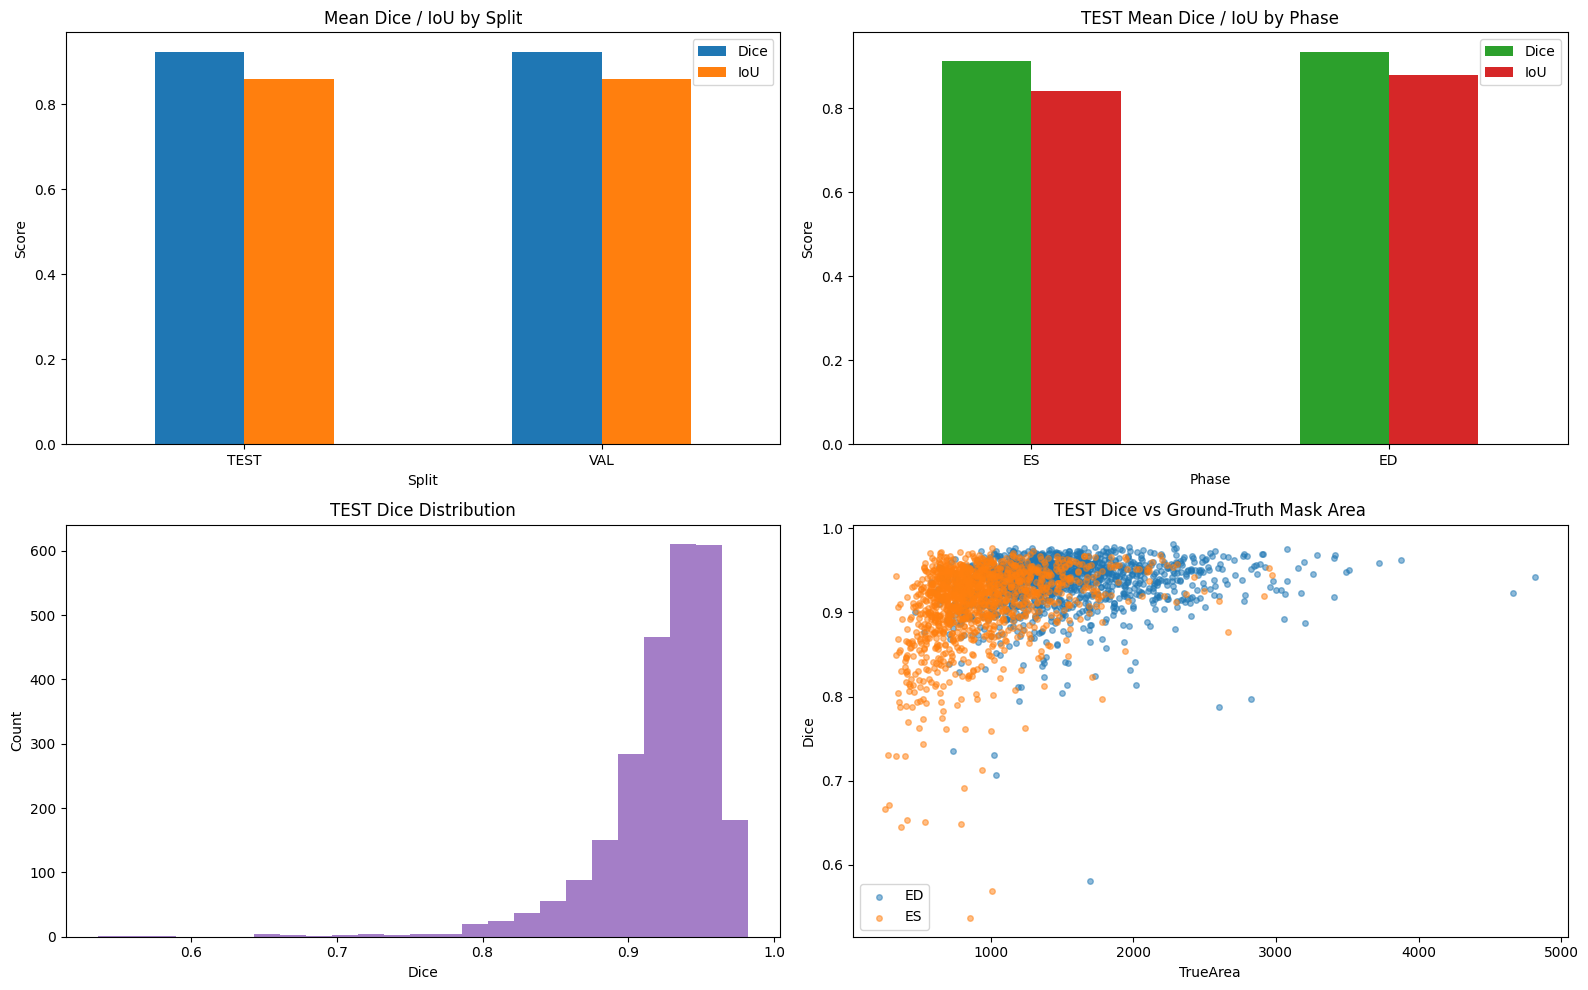

Saved overview figure to: /Users/emirarslan/Downloads/lab task/echo-project/segmentation/results/figures/unet_baseline_112_rgb_kaggle_eval_overview.png


In [10]:
test_only_df = sample_metrics_df[sample_metrics_df["Split"] == "TEST"].copy().reset_index(drop=True)
phase_colors = {"ES": "tab:orange", "ED": "tab:blue"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

split_means = sample_metrics_df.groupby("Split")[["Dice", "IoU"]].mean()
split_means.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Mean Dice / IoU by Split")
axes[0, 0].set_ylabel("Score")
axes[0, 0].tick_params(axis="x", rotation=0)

test_phase_means = test_only_df.groupby("Phase")[["Dice", "IoU"]].mean().reindex(["ES", "ED"])
test_phase_means.plot(kind="bar", ax=axes[0, 1], color=["tab:green", "tab:red"])
axes[0, 1].set_title("TEST Mean Dice / IoU by Phase")
axes[0, 1].set_ylabel("Score")
axes[0, 1].tick_params(axis="x", rotation=0)

axes[1, 0].hist(test_only_df["Dice"], bins=25, color="tab:purple", alpha=0.85)
axes[1, 0].set_title("TEST Dice Distribution")
axes[1, 0].set_xlabel("Dice")
axes[1, 0].set_ylabel("Count")

for phase, group in test_only_df.groupby("Phase"):
    axes[1, 1].scatter(
        group["TrueArea"],
        group["Dice"],
        s=16,
        alpha=0.5,
        label=phase,
        color=phase_colors.get(phase, None),
    )
axes[1, 1].set_title("TEST Dice vs Ground-Truth Mask Area")
axes[1, 1].set_xlabel("TrueArea")
axes[1, 1].set_ylabel("Dice")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(overview_figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved overview figure to:", overview_figure_path)


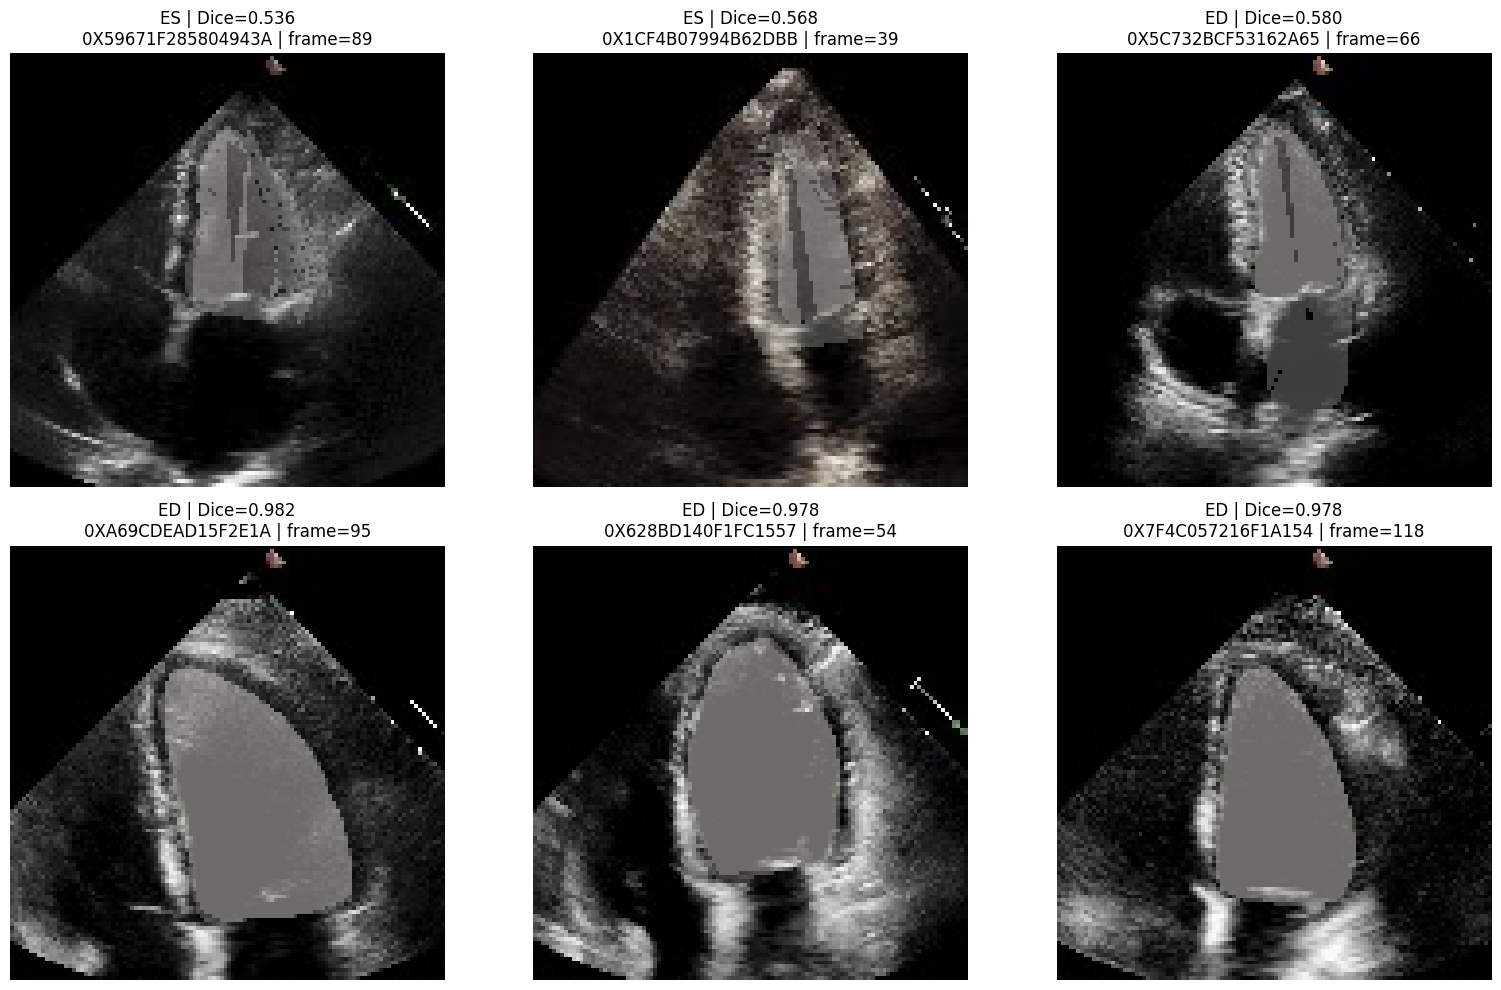

checkpoint_path            /Users/emirarslan/Downloads/lab task/echo-proj...
sample_metrics_path        /Users/emirarslan/Downloads/lab task/echo-proj...
split_summary_path         /Users/emirarslan/Downloads/lab task/echo-proj...
phase_summary_path         /Users/emirarslan/Downloads/lab task/echo-proj...
overview_figure_path       /Users/emirarslan/Downloads/lab task/echo-proj...
qualitative_figure_path    /Users/emirarslan/Downloads/lab task/echo-proj...
n_val_examples                                                          2576
n_test_examples                                                         2552
mean_test_dice                                                      0.923153
mean_test_iou                                                       0.859828
dtype: object

In [11]:
@torch.no_grad()
def predict_single_example(model, file_name: str, frame_idx: int):
    frame = load_frame(video_path_map[file_name], frame_idx).astype(np.float32) / 255.0
    points = trace_lookup[(file_name, int(frame_idx))]
    true_mask = build_mask_from_points(points, IMAGE_SHAPE).astype(np.uint8)

    image_tensor = torch.from_numpy(np.transpose(frame, (2, 0, 1))).unsqueeze(0).float().to(device)
    logits = model(image_tensor)
    probs = torch.sigmoid(logits)[0, 0].cpu().numpy()
    pred_mask = (probs >= THRESHOLD).astype(np.uint8)

    return frame, true_mask, pred_mask, probs


test_sorted = test_only_df.sort_values("Dice", ascending=True).reset_index(drop=True)
worst_examples = test_sorted.head(3)
best_examples = test_sorted.tail(3).sort_values("Dice", ascending=False)

qual_examples_df = pd.concat([worst_examples, best_examples], ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (_, row) in zip(axes, qual_examples_df.iterrows()):
    frame, true_mask, pred_mask, pred_probs = predict_single_example(
        model=model,
        file_name=row["FileName"],
        frame_idx=int(row["Frame"]),
    )

    ax.imshow(frame)
    ax.imshow(np.ma.masked_where(true_mask == 0, true_mask), alpha=0.25, cmap="Greens")
    ax.imshow(np.ma.masked_where(pred_mask == 0, pred_mask), alpha=0.25, cmap="Reds")
    ax.set_title(
        f"{row['Phase']} | Dice={row['Dice']:.3f}\n"
        f"{row['FileName']} | frame={int(row['Frame'])}"
    )
    ax.axis("off")

plt.tight_layout()
plt.savefig(qualitative_figure_path, dpi=150, bbox_inches="tight")
plt.show()

artifact_summary = pd.Series({
    "checkpoint_path": str(checkpoint_path),
    "sample_metrics_path": str(sample_metrics_path),
    "split_summary_path": str(split_summary_path),
    "phase_summary_path": str(phase_summary_path),
    "overview_figure_path": str(overview_figure_path),
    "qualitative_figure_path": str(qualitative_figure_path),
    "n_val_examples": int(len(val_df)),
    "n_test_examples": int(len(test_df)),
    "mean_test_dice": float(test_only_df["Dice"].mean()),
    "mean_test_iou": float(test_only_df["IoU"].mean()),
})

display(artifact_summary)
